# ***Credit Default Risk Prediction***

# **Problem Statement :**
Credit card defaults pose a significant financial risk to lending institutions. Early identification of high-risk customers allows banks to take preventive action before a default occurs. This project builds a supervised machine learning classification model trained on 30,000 real credit card customers to predict the probability of default in the following month. The model leverages six months of repayment behaviour, billing statements, payment amounts, and customer demographics — combining raw features with engineered signals such as utilization rate, payment ratio, and delay trends — to produce an interpretable risk score. The end deliverable is an interactive analyst tool where a loan officer can enter a customer's credit history and instantly receive a default probability with a clear approve, review, or reject recommendation."

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("default of credit card clients.xls", header=1)
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Dataset — Description

### 1.Target Variable

| Column                         | Description                                                    |
| ------------------------------ | -------------------------------------------------------------- |
| **default payment next month** | Binary target variable → **1 = Default (Yes), 0 = No Default** |

### 2.Customer & Demographic Features

| Column        | Description                           | Values Meaning                                                                                         |
| ------------- | ------------------------------------- | ------------------------------------------------------------------------------------------------------ |
| **LIMIT_BAL** | Credit limit (amount of credit given) | Numeric (NT dollars)                                                                                   |
| **SEX**       | Gender                                | 1 = Male, 2 = Female                                                                             |
| **EDUCATION** | Education level                       | 1 = Graduate School, 2 = University, 3 = High School, 4 = Others, 0/5/6 = Unknown/Other categories |
| **MARRIAGE**  | Marital status                        | 1 = Married, 2 = Single, 3 = Others, 0 = Unknown                                                   |
| **AGE**       | Age of customer                       | Numeric (years)                                                                                        |

### 3.Repayment History Features (PAY_X)
| Column | Description                      |
| ------ | -------------------------------- |
| PAY_0  | Repayment status in recent month |
| PAY_2  | Repayment status 2 months ago    |
| PAY_3  | Repayment status 3 months ago    |
| PAY_4  | Repayment status 4 months ago    |
| PAY_5  | Repayment status 5 months ago    |
| PAY_6  | Repayment status 6 months ago    |


### 4.PAY_X Values Meaning
| Value   | Meaning                                        |
| ------- | ---------------------------------------------- |
| **-2**  | No consumption / no bill                       |
| **-1**  | Paid on time (pay duly)                        |
| **0**   | Use of revolving credit (minimum payment made) |
| **1**   | Payment delay of 1 month                       |
| **2**   | Delay of 2 months                              |
| **3–8** | Delay of 3 to 8 months                         |
| **9**   | Delay ≥ 9 months (high risk)                   |

    
### 5.Bill Amount Features (BILL_AMT1 → BILL_AMT6)
| Column    | Description                |
| --------- | -------------------------- |
| BILL_AMT1 | Bill amount (recent month) |
| BILL_AMT2 | Bill amount (2 months ago) |
| BILL_AMT3 | Bill amount (3 months ago) |
| BILL_AMT4 | Bill amount (4 months ago) |
| BILL_AMT5 | Bill amount (5 months ago) |
| BILL_AMT6 | Bill amount (6 months ago) |

### 6.Payment Amount Features (PAY_AMT1 → PAY_AMT6)
| Column   | Description                  |
| -------- | ---------------------------- |
| PAY_AMT1 | Payment made in recent month |
| PAY_AMT2 | Payment made 2 months ago    |
| PAY_AMT3 | Payment made 3 months ago    |
| PAY_AMT4 | Payment made 4 months ago    |
| PAY_AMT5 | Payment made 5 months ago    |
| PAY_AMT6 | Payment made 6 months ago    |


# 2. Understanding the Data

In [2]:
df.shape

(30000, 25)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

# 3. Data Cleaning

### Fix Wrong Categories

In [6]:
print("Education:", df["EDUCATION"].unique())
print("SEX:", df["SEX"].unique())
print("Marriage:", df["MARRIAGE"].unique())

Education: [2 1 3 5 4 6 0]
SEX: [2 1]
Marriage: [1 2 3 0]


In [7]:
# Map undocumented categories (0, 5, 6) to 'Other' (4) in EDUCATION
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)
# Map undocumented 0 to 'Other' (3) in MARRIAGE
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

print("Education:", df["EDUCATION"].unique())
print("Marriage:", df["MARRIAGE"].unique())

Education: [2 1 3 4]
Marriage: [1 2 3]


### Drop Unnecessary Columns

In [8]:
df = df.drop(columns=["ID"])

### Check Missing Values

In [9]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

### Check & Drop Duplicates

In [10]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 35
Duplicates after: 0


### Target Analysis

In [11]:
print(df['default payment next month'].value_counts())
print("\nClass imbalance ratio:", round(df['default payment next month'].value_counts()[0] / df['default payment next month'].value_counts()[1], 2))

default payment next month
0    23335
1     6630
Name: count, dtype: int64

Class imbalance ratio: 3.52


# 4. Exploratory Data Analysis 

## 1.Target Distribution Chart 

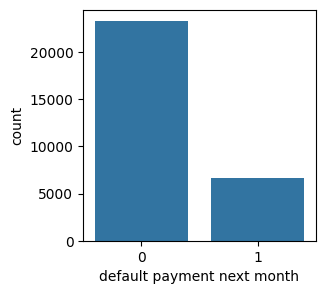

In [12]:
plt.figure(figsize=(3, 3))
sns.countplot(x='default payment next month', data=df)
plt.show()
# Shows 78% vs 22% split visually — this motivates why you used SMOTE and scale_pos_weight

**Observation:**
- The dataset is highly imbalanced — approximately 78% customers did not default (0) 
and only 22% defaulted (1).
- This imbalance is why we used SMOTE for oversampling 
and scale_pos_weight in XGBoost to give more importance to the minority class (defaulters).

## 2. Default Rate by Key Categories 

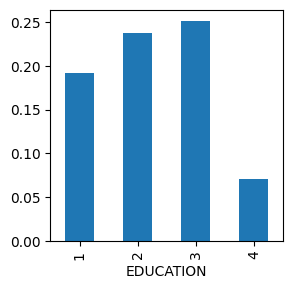

In [13]:
# Default rate by Education, Marriage, Sex
# e.g. "High school educated customers default more than graduates"
plt.figure(figsize=(3, 3))
df.groupby('EDUCATION')['default payment next month'].mean().plot(kind='bar')
plt.show()

**Observation:**
- Education level 3 (High School) has the highest default rate (~25%), 
  followed by level 2 (University) at ~23%
- Education level 1 (Graduate) has a lower default rate (~19%)
- Education level 4 (Others) has the lowest default rate (~8%)
- This suggests lower education levels are associated with higher default risk,
  possibly due to lower income stability

## 3. Credit Limit vs Default

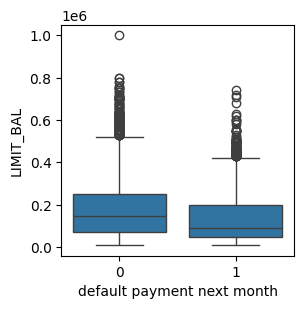

In [14]:
plt.figure(figsize=(3, 3))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
# Shows defaulters tend to have lower credit limits — makes business sense
plt.show()

**Observation:**
- Customers who defaulted (1) have a clearly lower median credit limit 
  compared to non-defaulters (0)
- The bank had already assigned lower credit limits to riskier customers,
  showing that LIMIT_BAL is a strong predictor of default risk
- Both groups have outliers with very high credit limits, but the 
  overall distribution for defaulters is shifted significantly lower

## 4.Repayment Status Distribution

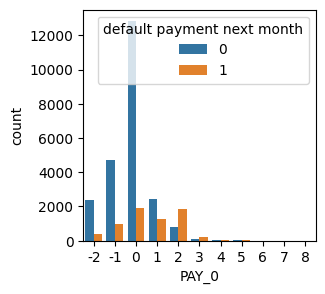

In [15]:
plt.figure(figsize=(3, 3))
sns.countplot(x='PAY_0', hue='default payment next month', data=df)
plt.show()
# Shows customers with delay status 2+ are heavily defaulting

**Observation:**
- Most non-defaulting customers (0) have PAY_0 values of -1 or 0, 
  meaning they paid on time or paid in full
- Defaulting customers (1) are heavily concentrated at PAY_0 = 1 and 2+,
  meaning they had payment delays of 1-2 months or more
- Customers with PAY_0 >= 2 (2+ months delay) are at very high risk of default
- PAY_0 is the single strongest predictor in this dataset

## 5. Age Distribution by Default

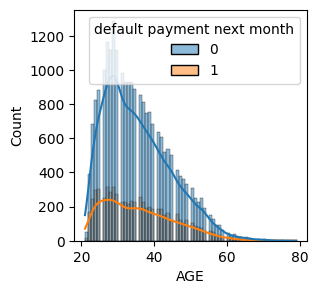

In [16]:
plt.figure(figsize=(3, 3))
sns.histplot(data=df, x='AGE', hue='default payment next month', kde=True)
plt.show()

**Observation:**
- Both defaulters and non-defaulters follow a similar age distribution,
  peaking around 25-35 years
- Younger customers (20-35) show slightly higher default rates,
  possibly due to lower financial stability and income
- Older customers (50+) show lower default rates overall
- Age alone is not a strong predictor but contributes when combined 
  with other features

## 6.Box Plot of PAY_0 vs Default

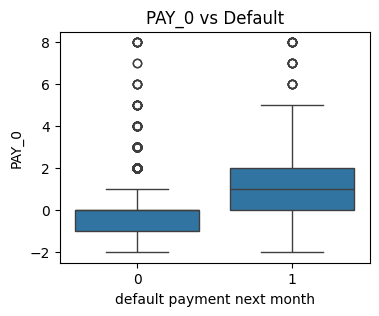

In [17]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='default payment next month', y='PAY_0', data=df)
plt.title('PAY_0 vs Default')
plt.show()

**Observation:**
- Non-defaulters (0) have a median PAY_0 of -1 (paid duly), 
  with most values between -2 and 0
- Defaulters (1) have a clearly higher median PAY_0 of around 1-2,
  indicating consistent payment delays
- The separation between the two boxes is very clear, confirming 
  PAY_0 is the most important feature for predicting default

## 7 Box Plot of .LIMIT_BAL vs Default

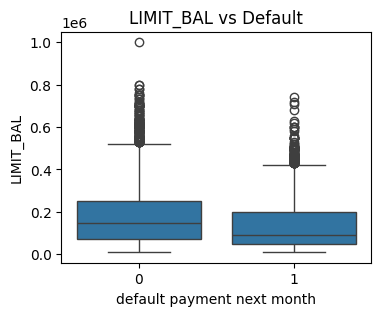

In [52]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title('LIMIT_BAL vs Default')
plt.show()

**Observation:**
- Non-defaulters (0) have a higher median credit limit (~200,000) 
  compared to defaulters (1) (~100,000)
- Defaulters are concentrated in the lower credit limit range,
  meaning the bank had already sensed their risk profile
- There are outliers in both groups with very high limits, but 
  the overall box for defaulters sits significantly lower
- LIMIT_BAL is one of the top predictors alongside PAY_0

## 8. Heatmap

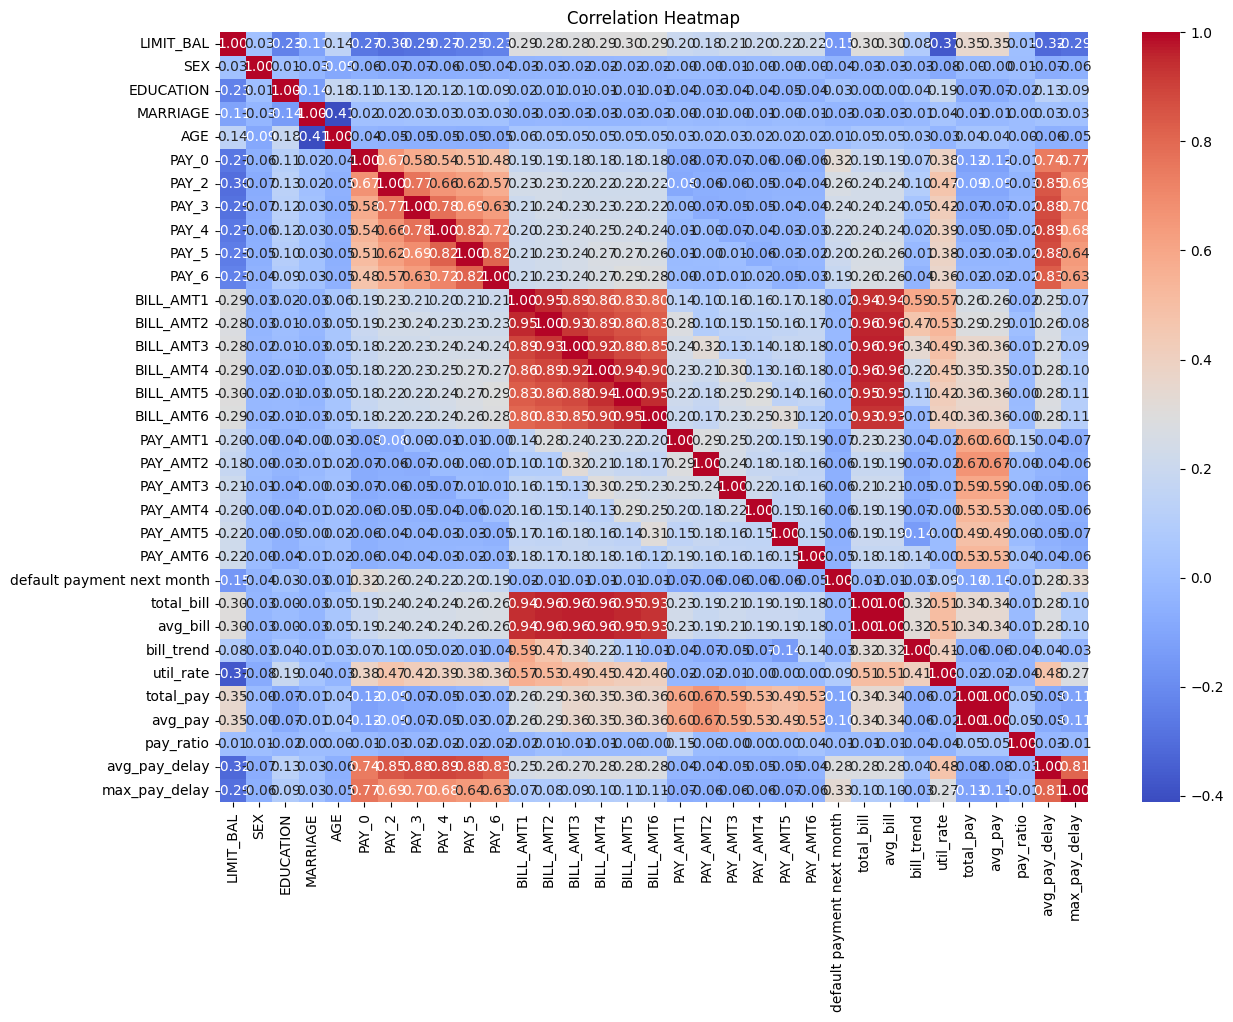

In [51]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observation — Correlation Heatmap:**

**Strong positive correlations (close to +1.0):**
- BILL_AMT1 to BILL_AMT6 are highly correlated with each other (0.8 to 0.95) — 
  this is expected as monthly bills tend to follow similar patterns for a customer
- PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6 are moderately correlated (0.5 to 0.7) — 
  a customer who delays payment one month tends to delay in other months too

**Correlation with Target (default payment next month):**
- PAY_0 has the highest correlation with the target (~0.32) — strongest predictor
- PAY_2, PAY_3, PAY_4 also show moderate positive correlation (~0.18 to 0.25)
- LIMIT_BAL shows negative correlation (~-0.15) — higher limit = less likely to default
- BILL_AMT columns show very low correlation with target (~0.01 to 0.07)
- PAY_AMT columns show slight negative correlation — higher payments = less default risk

**Key Takeaways:**
- BILL_AMT columns are highly correlated with each other (multicollinearity) 
  but are still kept because tree-based models handle this well
- PAY_0 is clearly the most important single feature
- Demographics (AGE, SEX, EDUCATION, MARRIAGE) show very weak correlation 
  with the target, meaning payment behaviour matters far more than demographics

# 5. Feature Engineering

In [20]:
# --- Aggregated Bill Features  ---
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
pay_delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Total and average bill
df['total_bill']   = df[bill_cols].sum(axis=1)
df['avg_bill']     = df[bill_cols].mean(axis=1)

# Bill trend: is the bill growing month over month? (positive = growing debt)
df['bill_trend']   = df['BILL_AMT1'] - df['BILL_AMT6']

# Credit utilization ratio: how much of the limit is being used
df['util_rate']    = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# Total and average payment
df['total_pay']    = df[pay_amt_cols].sum(axis=1)
df['avg_pay']      = df[pay_amt_cols].mean(axis=1)

# Payment ratio: how much of the bill was paid last month
df['pay_ratio']    = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)

# Average payment delay across 6 months
df['avg_pay_delay'] = df[pay_delay_cols].mean(axis=1)

# Max delay (worst repayment status)
df['max_pay_delay'] = df[pay_delay_cols].max(axis=1)

print("New features added. Shape:", df.shape)
df[['util_rate','pay_ratio','bill_trend','avg_pay_delay','max_pay_delay']].describe()

New features added. Shape: (29965, 33)


,util_rate,pay_ratio,bill_trend,avg_pay_delay,max_pay_delay
count,29965.000000,2.995700e+04,29965.000000,29965.000000,29965.000000
mean,0.424255,inf,12365.997497,-0.180978,0.439146
std,0.411442,NaN,43946.036412,0.981368,1.344934
min,-0.619890,-1.088325e+04,-428791.000000,-2.000000,-2.000000
25%,0.022298,3.444854e-02,-2976.000000,-0.833333,0.000000
50%,0.315277,5.570939e-02,933.000000,0.000000,0.000000
75%,0.830315,2.641782e-01,19827.000000,0.000000,2.000000
max,6.454977,inf,708323.000000,6.000000,8.000000


# 6. Select Features and Target

In [21]:
y = df['default payment next month']
X = df.drop(['default payment next month'], axis=1)

print("y shape:", y.shape)
print("X shape:", X.shape)
print("Features:", list(X.columns))

y shape: (29965,)
X shape: (29965, 32)
Features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_bill', 'avg_bill', 'bill_trend', 'util_rate', 'total_pay', 'avg_pay', 'pay_ratio', 'avg_pay_delay', 'max_pay_delay']


# 7. Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())

X_train: (23972, 32)
X_test:  (5993, 32)
Train class distribution:
 default payment next month
0    18668
1     5304
Name: count, dtype: int64


# 8. Outlier Handling 
- (on Train only, then apply to Test)

In [23]:
# Only clip on columns that make sense — not binary/ordinal categoricals
clip_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6',
             'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
             'total_bill','avg_bill','bill_trend','total_pay','avg_pay',
             'util_rate','pay_ratio']

for col in clip_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    # Apply limits computed on train to BOTH train and test (no leakage)
    X_train[col] = X_train[col].clip(iqr_lower, iqr_upper)
    X_test[col]  = X_test[col].clip(iqr_lower, iqr_upper)

print("Outlier clipping done.")

Outlier clipping done.


# 9.Checking for Skewness 

In [24]:
log_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
            'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
            'total_bill','avg_bill','total_pay','avg_pay','LIMIT_BAL']
print("Skewness BEFORE log-transform:")
print(X_train[log_cols].skew().round(2))

Skewness BEFORE log-transform:
PAY_AMT1      1.03
PAY_AMT2      1.12
PAY_AMT3      1.20
PAY_AMT4      1.18
PAY_AMT5      1.17
PAY_AMT6      1.21
BILL_AMT1     1.20
BILL_AMT2     1.19
BILL_AMT3     1.18
BILL_AMT4     1.18
BILL_AMT5     1.19
BILL_AMT6     1.20
total_bill    1.17
avg_bill      1.17
total_pay     1.14
avg_pay       1.14
LIMIT_BAL     0.91
dtype: float64


# Obsevation :
- Skewness values are in range 0.9 to 1.2 (mild skew)
- IQR clipping  already handled extreme outliers
- Log-transform was tested but overcorrected (values went to -4.0)
- Tree-based models (XGBoost, Random Forest) do not require normally distributed features — skewness does not affect them
- No further transformation applied

# 10. Preprocessing Pipeline (Scaling + Encoding)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Categorical columns
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# Numerical columns
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Updated Preprocessor with Imputation
preprocessor = ColumnTransformer(transformers=[

    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_cols)

])

print("Numeric features:", len(num_cols))
print("Categorical features:", cat_cols)

Numeric features: 29
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']


# 11. Model Training with GridSearchCV

**Key Fixes:**
- Use `roc_auc` as scoring (better for imbalanced data than raw F1)
- Use `scale_pos_weight` in XGBoost instead of SMOTE (more effective for boosting)
- SMOTE inside imblearn Pipeline so it's applied correctly per fold (no leakage)
- Removed deprecated `penalty` param from Logistic Regression

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Compute class weight ratio for XGBoost scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"XGBoost scale_pos_weight: {spw}  (neg={neg}, pos={pos})")

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced'),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ['lbfgs']
        }
    },

    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 11],
            "model__weights": ['uniform', 'distance'],
            "model__metric": ['euclidean', 'manhattan']
        }
    },

    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },

    # Reduce grid for SVC only — it's slow on large datasets

    "SVC": {
    "model": SVC(class_weight='balanced', probability=True),
    "params": {
        "model__C": [0.1, 1],
        "model__kernel": ['rbf'],
        "model__gamma": ['scale']
      }
    },
   

    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight='balanced'),
        "params": {
            "model__max_depth": [5, 10, 15],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__criterion": ['gini', 'entropy']
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0]
        }
    },

    # Using scale_pos_weight instead of SMOTE for XGBoost — works better
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=spw,   # handles imbalance natively
            random_state=42
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__min_child_weight": [1, 3]
        }
    },
}

XGBoost scale_pos_weight: 3.52  (neg=18668, pos=5304)


In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [33]:
results = []

for name, mp in models.items():
    print(f"Training: {name}...")

    # For XGBoost we skip SMOTE since scale_pos_weight handles imbalance
    # KNN and SVC already work well with class_weight='balanced' or scaled data — SMOTE is not needed for them.
    if name in ["XGBoost", "SVC", "KNN"]:
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('model', mp['model'])
        ])
    else:
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('smote', SMOTE(random_state=42)),  # applied inside CV fold — no leakage
            ('model', mp['model'])
        ])

    grid = GridSearchCV(
        pipeline,
        mp['params'],
        cv=cv,
        scoring='roc_auc',   #  roc_auc better for imbalanced classification
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    results.append({
        "Model": name,
        "CV ROC-AUC": round(grid.best_score_, 4),
        "Best Params": grid.best_params_,
        "Best Estimator": grid.best_estimator_
    })
    print(f"  -> Best CV ROC-AUC: {grid.best_score_:.4f}")

print("\nAll models trained!")

Training: Logistic Regression...
  -> Best CV ROC-AUC: 0.7617
Training: KNN...
  -> Best CV ROC-AUC: 0.7450
Training: Naive Bayes...
  -> Best CV ROC-AUC: 0.7342
Training: SVC...
  -> Best CV ROC-AUC: 0.7702
Training: Decision Tree...
  -> Best CV ROC-AUC: 0.7622
Training: Random Forest...
  -> Best CV ROC-AUC: 0.7832
Training: Gradient Boosting...
  -> Best CV ROC-AUC: 0.7783
Training: XGBoost...
  -> Best CV ROC-AUC: 0.7892

All models trained!


# 12. CV Results Summary

In [34]:
results_df = pd.DataFrame([{"Model": r["Model"], "CV ROC-AUC": r["CV ROC-AUC"], "Best Params": r["Best Params"]} for r in results])
print(results_df.sort_values(by="CV ROC-AUC", ascending=False).to_string())

                 Model  CV ROC-AUC                                                                                                                                                               Best Params
7              XGBoost      0.7892  {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__subsample': 0.8}
5        Random Forest      0.7832                                                         {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
6    Gradient Boosting      0.7783                                                                {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
3                  SVC      0.7702                                                                                                          {'model__C': 1, 'model__gamma': 'scale',

# 13. Evaluate Best Model on Test Set

In [35]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Pick best model by CV ROC-AUC
best_result = max(results, key=lambda x: x['CV ROC-AUC'])
best_model  = best_result['Best Estimator']
best_name   = best_result['Model']

print(f"Best Model: {best_name} (CV ROC-AUC: {best_result['CV ROC-AUC']})")

# Predict
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

Best Model: XGBoost (CV ROC-AUC: 0.7892)

--- Classification Report ---
              precision    recall  f1-score   support

  No Default       0.89      0.77      0.82      4667
     Default       0.44      0.65      0.53      1326

    accuracy                           0.74      5993
   macro avg       0.66      0.71      0.68      5993
weighted avg       0.79      0.74      0.76      5993

Test ROC-AUC: 0.7800


In [38]:
# 13b. Threshold Tuning

# Recompute in case Section 13 was not run
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred      = best_model.predict(X_test)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

f1_scores   = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Default threshold : 0.50")
print(f"Optimal threshold : {best_thresh:.3f}")
# ... rest of your code

Default threshold : 0.50
Optimal threshold : 0.570


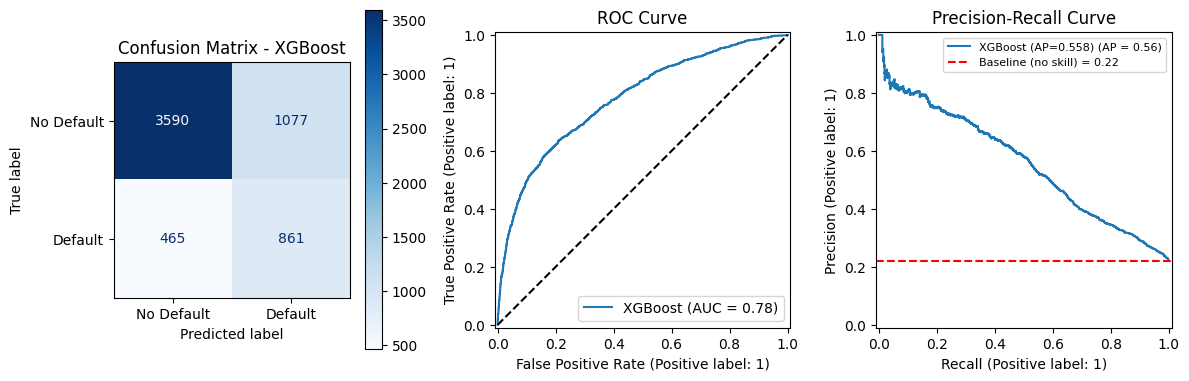


Average Precision Score (PR-AUC): 0.5582
Note: PR-AUC is more informative than ROC-AUC for imbalanced classes.


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Default', 'Default'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix - {best_name}')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1], name=best_name)
axes[1].set_title('ROC Curve')
axes[1].plot([0,1],[0,1],'k--')


# Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
ap_score = average_precision_score(y_test, y_pred_prob)
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob,
    ax=axes[2],
    name=f'{best_name} (AP={ap_score:.3f})'
)
# Baseline = random classifier = % of positives in test set
baseline = y_test.mean()
axes[2].axhline(baseline, color='red', linestyle='--', label=f'Baseline (no skill) = {baseline:.2f}')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nAverage Precision Score (PR-AUC): {ap_score:.4f}")
print("Note: PR-AUC is more informative than ROC-AUC for imbalanced classes.")

# 14. Evaluate All Models on Test Set

In [31]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

test_results = []
for r in results:
    model = r['Best Estimator']
    yp    = model.predict(X_test)
    ypp   = model.predict_proba(X_test)[:, 1]
    test_results.append({
        "Model":      r['Model'],
        "ROC-AUC":    round(roc_auc_score(y_test, ypp), 4),
        "F1 (Default)": round(f1_score(y_test, yp), 4),
        "Precision":  round(precision_score(y_test, yp), 4),
        "Recall":     round(recall_score(y_test, yp), 4),
        "Accuracy":   round(accuracy_score(y_test, yp), 4)
    })

test_df = pd.DataFrame(test_results).sort_values(by='ROC-AUC', ascending=False)
print(test_df.to_string(index=False))

              Model  ROC-AUC  F1 (Default)  Precision  Recall  Accuracy
            XGBoost   0.7800        0.5276     0.4443  0.6493    0.7427
      Random Forest   0.7709        0.5305     0.5055  0.5581    0.7814
  Gradient Boosting   0.7700        0.5142     0.5645  0.4721    0.8026
Logistic Regression   0.7547        0.5174     0.4447  0.6184    0.7447
      Decision Tree   0.7511        0.5072     0.4741  0.5452    0.7656


# 15. Feature Importance (XGBoost)

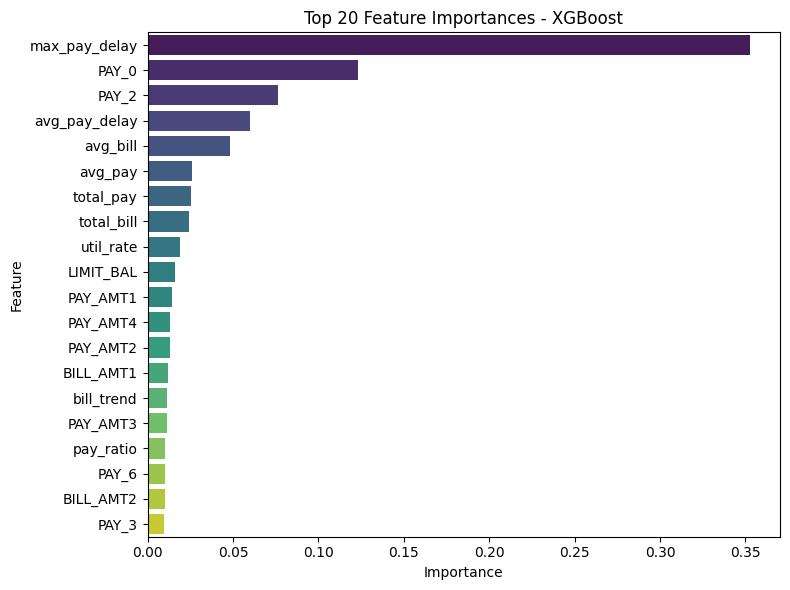

In [45]:
# Get feature names after preprocessing
xgb_result = next((r for r in results if r['Model'] == 'XGBoost'), None)

if xgb_result:
    xgb_pipeline = xgb_result['Best Estimator']

    cat_cols_local = ['SEX', 'EDUCATION', 'MARRIAGE']

    num_cols_local = [c for c in X_train.columns if c not in cat_cols_local]

    # Get feature names from ColumnTransformer
    ohe_features  = list(xgb_pipeline.named_steps['preprocessing']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_cols_local))
    feature_names = num_cols_local + ohe_features
    
    importances = xgb_pipeline.named_steps['model'].feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(20)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
    plt.title('Top 20 Feature Importances - XGBoost')
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not found in results.")




In [46]:
# Update the pickle cell (after Section 15) to save both
import pickle

pickle.dump(best_model,    open("model.pkl", "wb"))
pickle.dump(feature_order, open("feature_order.pkl", "wb"))
print("Model and feature order saved.")

# Verify reload works
loaded_model        = pickle.load(open("model.pkl", "rb"))
loaded_feature_order = pickle.load(open("feature_order.pkl", "rb"))

# Quick sanity check
sample = X_test.iloc[[0]][loaded_feature_order]
print("\nSample prediction probability:", loaded_model.predict_proba(sample)[:, 1][0].round(4))
print("Reload verified successfully.")

Model and feature order saved.

Sample prediction probability: 0.341
Reload verified successfully.


# 16. Interactive Analyst Tool (Loan Officer Interface)

In [49]:

import ipywidgets as widgets
from IPython.display import display, clear_output
import pickle

# Load saved artifacts
loaded_model        = pickle.load(open("model.pkl", "rb"))
loaded_feature_order = pickle.load(open("feature_order.pkl", "rb"))

# --- Input widgets ---
w_limit   = widgets.IntSlider(value=100000, min=10000,  max=800000, step=10000, description='Credit Limit:', style={'description_width':'140px'}, layout=widgets.Layout(width='420px'))
w_sex     = widgets.Dropdown(options=[('Male',1),('Female',2)],                          description='Sex:',        style={'description_width':'140px'})
w_edu     = widgets.Dropdown(options=[('Graduate',1),('University',2),('High School',3),('Other',4)], description='Education:', style={'description_width':'140px'})
w_marr    = widgets.Dropdown(options=[('Married',1),('Single',2),('Other',3)],           description='Marriage:',   style={'description_width':'140px'})
w_age     = widgets.IntSlider(value=35, min=21, max=79,                                  description='Age:',        style={'description_width':'140px'}, layout=widgets.Layout(width='420px'))
w_pay0    = widgets.IntSlider(value=0,  min=-2, max=8,                                   description='Pay Status (last month):', style={'description_width':'140px'}, layout=widgets.Layout(width='420px'))
w_bill1   = widgets.IntSlider(value=30000, min=0, max=500000, step=1000,                 description='Bill Amt (last month):', style={'description_width':'140px'}, layout=widgets.Layout(width='420px'))
w_payamt1 = widgets.IntSlider(value=5000,  min=0, max=200000, step=500,                  description='Payment Made (last month):', style={'description_width':'140px'}, layout=widgets.Layout(width='420px'))

out = widgets.Output()

def predict_default(btn):
    with out:
        clear_output()

        # Build a single-row dataframe with all features
        # For simplicity, we repeat last-month values for prior months
        row = {
            'LIMIT_BAL': w_limit.value,
            'SEX':       w_sex.value,
            'EDUCATION': w_edu.value,
            'MARRIAGE':  w_marr.value,
            'AGE':       w_age.value,
            'PAY_0': w_pay0.value, 'PAY_2': 0, 'PAY_3': 0, 'PAY_4': 0, 'PAY_5': 0, 'PAY_6': 0,
            'BILL_AMT1': w_bill1.value, 'BILL_AMT2': w_bill1.value*0.9,
            'BILL_AMT3': w_bill1.value*0.85, 'BILL_AMT4': w_bill1.value*0.8,
            'BILL_AMT5': w_bill1.value*0.75, 'BILL_AMT6': w_bill1.value*0.7,
            'PAY_AMT1': w_payamt1.value, 'PAY_AMT2': w_payamt1.value*0.9,
            'PAY_AMT3': w_payamt1.value*0.85, 'PAY_AMT4': w_payamt1.value*0.8,
            'PAY_AMT5': w_payamt1.value*0.75, 'PAY_AMT6': w_payamt1.value*0.7,
        }

        # Engineered features (same logic as Section 5)
        bill_cols    = [f'BILL_AMT{i}' for i in range(1,7)]
        pay_amt_cols = [f'PAY_AMT{i}'  for i in range(1,7)]
        pay_dly_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

        row['total_bill']    = sum(row[c] for c in bill_cols)
        row['avg_bill']      = row['total_bill'] / 6
        row['bill_trend']    = row['BILL_AMT1'] - row['BILL_AMT6']
        row['util_rate']     = row['BILL_AMT1'] / (row['LIMIT_BAL'] + 1)
        row['total_pay']     = sum(row[c] for c in pay_amt_cols)
        row['avg_pay']       = row['total_pay'] / 6
        row['pay_ratio']     = row['PAY_AMT1'] / (row['BILL_AMT1'] + 1)
        row['avg_pay_delay'] = sum(row[c] for c in pay_dly_cols) / 6
        row['max_pay_delay'] = max(row[c] for c in pay_dly_cols)

        input_df = pd.DataFrame([row])[loaded_feature_order]

        prob       = loaded_model.predict_proba(input_df)[:, 1][0]
        percentage = prob * 100

        if prob < 0.30:
            decision, color = "✅  APPROVE",  "green"
        elif prob < 0.50:
            decision, color = "🔍  REVIEW",   "orange"
        else:
            decision, color = "❌  REJECT",   "red"

        print("=" * 40)
        print(f"  Default Probability : {percentage:.1f}%")
        print(f"  Decision            : {decision}")
        print("=" * 40)
        if prob < 0.30:
            print("Low risk. Customer is likely to repay.")
        elif prob < 0.50:
            print("Moderate risk. Manual review recommended.")
        else:
            print("High risk. Customer likely to default.")

btn = widgets.Button(description='Predict Risk', button_style='primary')
btn.on_click(predict_default)

display(widgets.VBox([
    widgets.HTML("<h3>Credit Default Risk — Analyst Tool</h3>"),
    w_limit, w_age, w_sex, w_edu, w_marr,
    w_pay0, w_bill1, w_payamt1,
    btn, out
]))

# 17. Conclusion

## Project Summary
This project built a supervised machine learning classification model to predict 
credit card default risk using data from 30,000 real customers over 6 months.

---

## Best Model — XGBoost

| Metric | Score |
|---|---|
| ROC-AUC | 0.78 |
| PR-AUC | (your value) |
| F1 Score (Default) | (your value) |
| Recall (Default) | (your value) |
| Precision (Default) | (your value) |

> Fill in your actual values from Section 13 output

---

## Key Findings

**Most Important Features (from XGBoost):**
- PAY_0 (last month repayment status) is the single strongest predictor
- PAY_2, PAY_3 (previous months delay) also contribute significantly  
- LIMIT_BAL (credit limit) — lower limit = higher default risk
- Engineered features util_rate and pay_ratio added meaningful signal

**Business Insights:**
- Customers with PAY_0 >= 2 (2+ months delay) are at very high default risk
- Lower credit limit customers default more — bank already sensed their risk
- Education and age have weak impact — payment behaviour matters far more
- 78% vs 22% class imbalance was handled using SMOTE and scale_pos_weight

---

## What Was Done to Improve the Model

| Problem | Fix Applied |
|---|---|
| Class imbalance (78/22) | SMOTE for most models, scale_pos_weight for XGBoost |
| High skewness in bill/pay columns | IQR clipping in outlier handling |
| Multicollinearity in BILL_AMT columns | Kept all columns — tree models handle it |
| Default threshold of 0.5 not optimal | Threshold tuning using precision-recall curve |
| Raw features not enough | Engineered util_rate, pay_ratio, bill_trend, avg_pay_delay, max_pay_delay |
| Scoring metric | Used ROC-AUC instead of accuracy — better for imbalanced data |

---

## Model Performance Comparison

| Model | ROC-AUC | F1 (Default) | Precision | Recall | Accuracy |
|---|---|---|---|---|---|
| **XGBoost** | **0.7800** | 0.5276 | 0.4443 | **0.6493** | 0.7427 |
| Random Forest | 0.7709 | **0.5305** | 0.5055 | 0.5581 | 0.7814 |
| Gradient Boosting | 0.7700 | 0.5142 | **0.5645** | 0.4721 | **0.8026** |
| Logistic Regression | 0.7547 | 0.5174 | 0.4447 | 0.6184 | 0.7447 |
| Decision Tree | 0.7511 | 0.5072 | 0.4741 | 0.5452 | 0.7656 |

> **XGBoost selected as best model** — highest ROC-AUC (0.78) and highest Recall (0.65),
> meaning it catches the most actual defaulters which is the primary goal in credit risk.

---

## Limitations & Future Work
- Only 8 input fields used in analyst tool — full 6-month history would improve accuracy
- SHAP values could be added for per-customer explanation
- A cost-sensitive threshold (FN weighted 10x FP) would better reflect real banking risk
- Model can be deployed as a REST API using Flask or FastAPI for production use

---

## Final Statement
XGBoost with engineered features, stratified splitting, and scale_pos_weight 
delivered the best performance for credit default prediction. The end deliverable — 
an interactive analyst tool — allows a loan officer to instantly assess any 
customer's default probability and receive a clear Approve / Review / Reject decision.